In [1]:
import os
import gc
import cdflib # for cdf load 
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, time, date
import matplotlib.pyplot as plt
import glob
from typing import Dict, Union
from chaosmagpy import load_CHAOS_matfile
from chaosmagpy.coordinate_utils import transform_points
from chaosmagpy.coordinate_utils import geo_to_gg
from chaosmagpy.data_utils import mjd2000, load_RC_datfile
from my_utils import load_cdf_file, load_folder_to_dataframe, mjd2000_to_datetime, datetime_to_mjd2000, gd2gc, gc2gd, my_chaos, load_omni

In [2]:
def find_crustal_bias_fast(data, bins=500, iqr_factor=3):
    """
    Find peak using histogram, after clipping outliers via IQR.
    iqr_factor: how many IQRs either side of the median to keep.
    """
    data = data.dropna()
    
    # Clip to median ± N * IQR  (robust to outliers, unlike std)
    median = data.median()
    iqr = data.quantile(0.75) - data.quantile(0.25)
    data_clipped = data[(data >= median - iqr_factor * iqr) & 
                        (data <= median + iqr_factor * iqr)]
    
    counts, bin_edges = np.histogram(data_clipped, bins=bins)
    peak_bin = np.argmax(counts)
    peak = (bin_edges[peak_bin] + bin_edges[peak_bin + 1]) / 2
    return peak

In [ ]:
year = '2025'

# Load and merge OMNI data (keep only time_mjd + needed cols for CHAOS)
df_omni, _ = load_omni(f'omni_files/omni_{year}.lst', hourly=True)
df_omni['time_mjd'] = df_omni.index.map(datetime_to_mjd2000)

# Load CHAOS model
model = load_CHAOS_matfile(glob.glob('CHAOS-*.mat')[0])
rc = load_RC_datfile(glob.glob('RC*.dat')[0])

# dtu station locations
df_stations = pd.read_csv('dtu_stations.csv')

In [ ]:
folders = ['ATU1','DMH2','FHB1','GDH4','HOV1m','KUL2','KUV1','NAQ4m','NRD2','PIF4','SCO2','SKT1','STF2','SUM1','SVS1','TAB2','THL4','UMQ1m','UPN2']

#folders = ['NRD2','PIF4']

df_bias = pd.DataFrame(index = folders, columns=['IAGA','bias_x','bias_y','bias_z'])

Found 29 files in 'dtu_downloads/NRD2/2026'

Done! Combined DataFrame shape: (41760, 5)
Computing core field.
Computing crustal field up to degree 110.


/home/william/miniconda3/envs/kandidat/lib/python3.11/site-packages/chaosmagpy/chaos.py:376: UserWarning: Requested coefficients are outside of the model time period from -1058.5000000000332 to 9533.499999999967 Modified Julian Date 2000. Doing linear extrapolation of the coefficient time series.
  coeffs = super().synth_coeffs(time, dim=dim, deriv=deriv,


Computing field due to external sources, incl. induced field: GSM.
Computing field due to external sources, incl. induced field: SM.
Computing field due to external sources, incl. ionospheric field.


/home/william/miniconda3/envs/kandidat/lib/python3.11/site-packages/chaosmagpy/chaos.py:1649: UserWarning: Requested coefficients are outside of the model period from -1058.5000000000332 to 9533.499999999967. Doing linear extrapolation of the coefficients in the GSM reference frame.
  warnings.warn(
/home/william/miniconda3/envs/kandidat/lib/python3.11/site-packages/chaosmagpy/chaos.py:1857: UserWarning: Requested coefficients are outside of the model period from -300.0 to 9533.499999999967. Doing linear extrapolation of the coefficients in the SM reference frame.
  warnings.warn(


NRD done!
Found 29 files in 'dtu_downloads/PIF4/2026'

Done! Combined DataFrame shape: (41760, 5)
Computing core field.
Computing crustal field up to degree 110.


/home/william/miniconda3/envs/kandidat/lib/python3.11/site-packages/chaosmagpy/chaos.py:376: UserWarning: Requested coefficients are outside of the model time period from -1058.5000000000332 to 9533.499999999967 Modified Julian Date 2000. Doing linear extrapolation of the coefficient time series.
  coeffs = super().synth_coeffs(time, dim=dim, deriv=deriv,


Computing field due to external sources, incl. induced field: GSM.
Computing field due to external sources, incl. induced field: SM.
Computing field due to external sources, incl. ionospheric field.


/home/william/miniconda3/envs/kandidat/lib/python3.11/site-packages/chaosmagpy/chaos.py:1649: UserWarning: Requested coefficients are outside of the model period from -1058.5000000000332 to 9533.499999999967. Doing linear extrapolation of the coefficients in the GSM reference frame.
  warnings.warn(
/home/william/miniconda3/envs/kandidat/lib/python3.11/site-packages/chaosmagpy/chaos.py:1857: UserWarning: Requested coefficients are outside of the model period from -300.0 to 9533.499999999967. Doing linear extrapolation of the coefficients in the SM reference frame.
  warnings.warn(


PIF done!


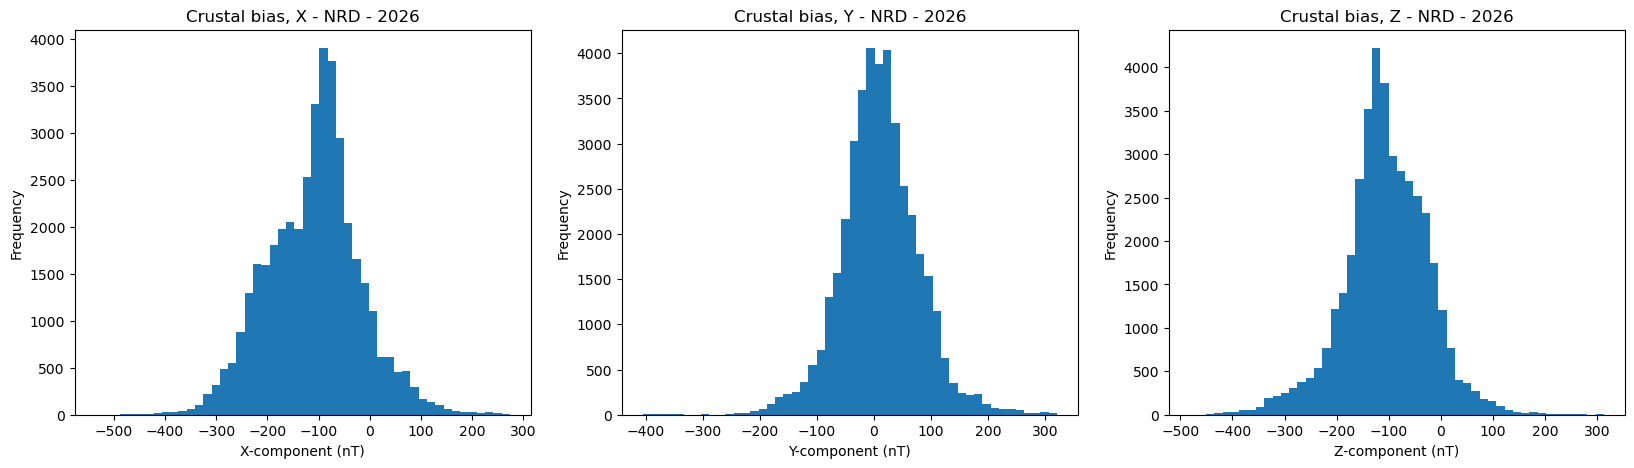

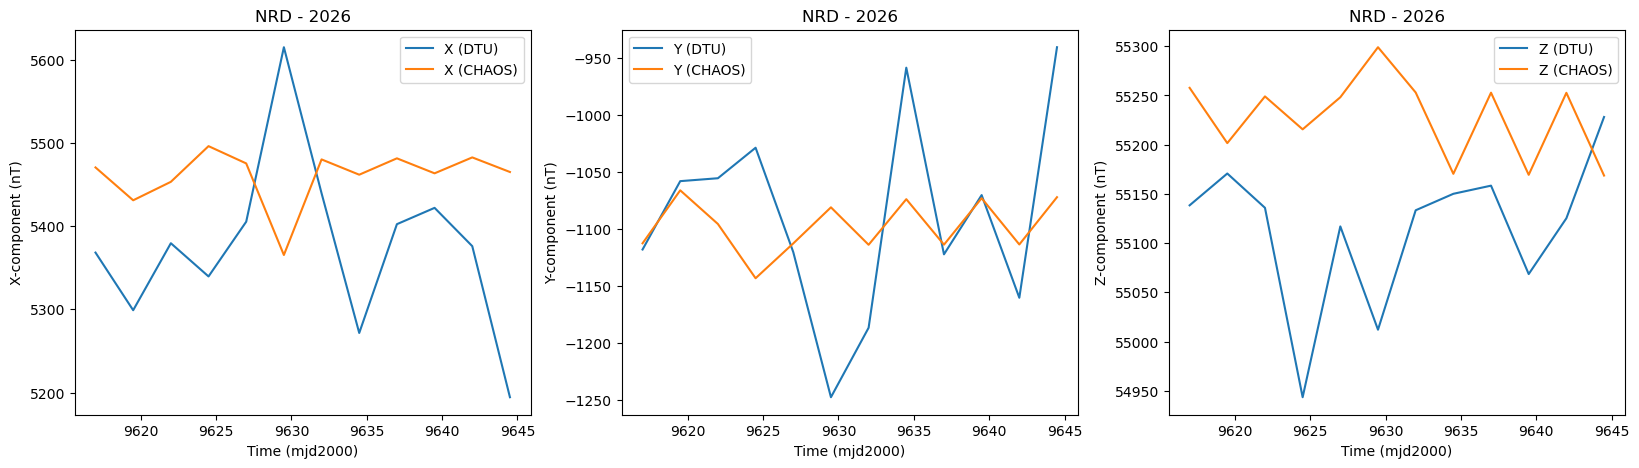

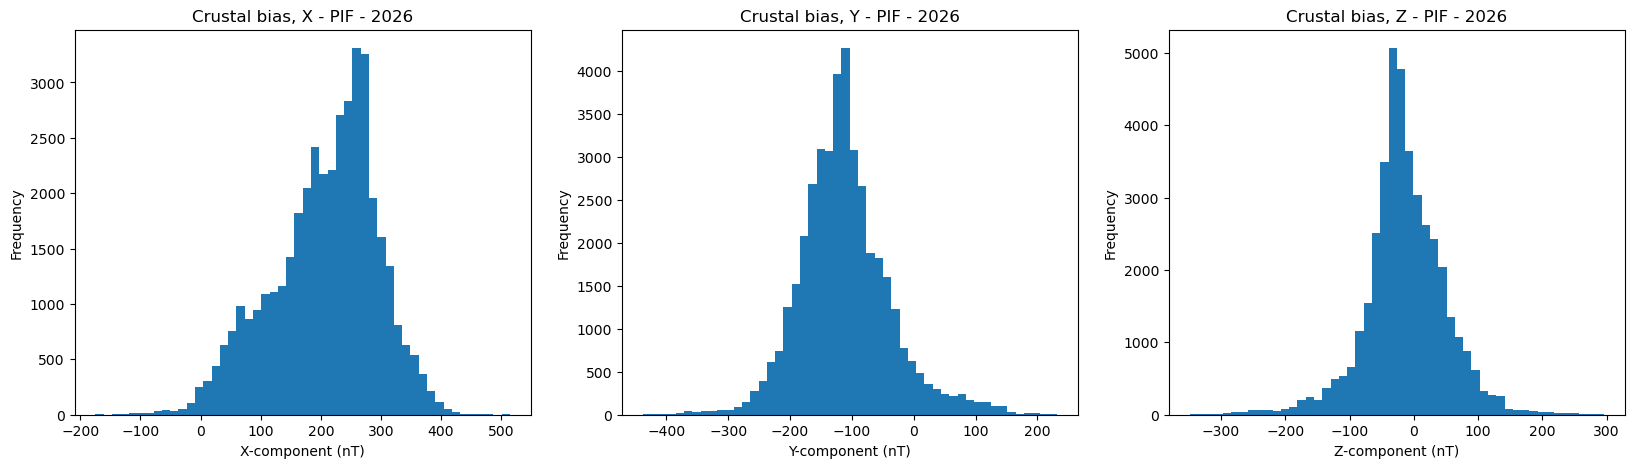

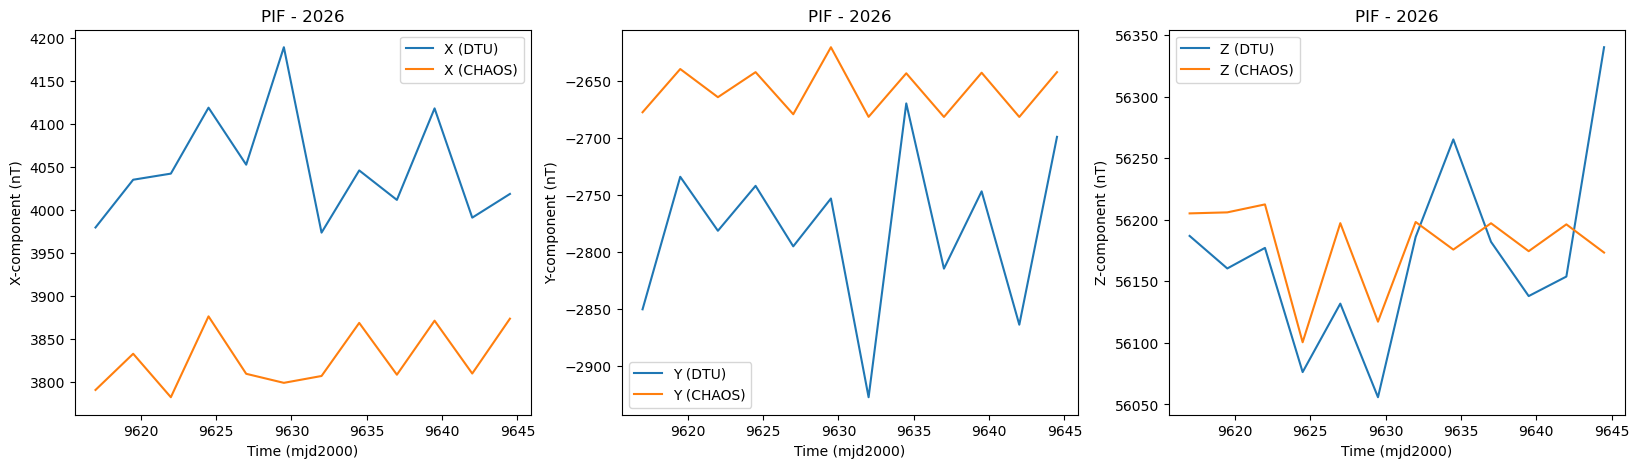

In [8]:
i = 0

for folder in folders:

    # Load and clean data
    #folder_path = "dtu_downloads/UPN2"
    folder_path = f"dtu_downloads/{folder}/{year}"
    station = folder[0:3]

    # skip if folder is empty
    if not os.listdir(folder_path):
        print(f'no files in directory ({station}), skipped to next station')
        i = i+1
        continue
    
    df = load_folder_to_dataframe(folder_path, minute=True).dropna(subset=['X', 'Y', 'Z'])
    df = df[df['Z']<65000] # remove worst outliers


    # skip if generated df is empty (happens some times, idk why)
    if df.empty:
        print(f"DataFrame is empty for {station}, skipped to next station")
        i = i+1
        continue

    STA = df_stations[df_stations['IAGA']==station] # get station coordinates

    # hourly omni df matched to times in data df
    df_omni_hourly = (
        pd.merge_asof(
            df.sort_values('time_mjd')[['time_mjd']],  # only bring time_mjd from df
            df_omni.sort_values('time_mjd'),
            on='time_mjd',
            direction='nearest'
        )
        .iloc[::3600]
    )

    # geocentric coordinates of station for CHAOS use
    r, colat_gc, Z_gc, X_gc = gd2gc(STA['lat_gd'].values, 0, df['X'].values, df['Z'].values) # using 0km height (Maries recommendation)
    lon_gc = STA['lon_gd'].values
    Y_gc = df['Y'].values # same in gd and gc

    # Run CHAOS on hourly time steps
    time_hourly = df['time_mjd'].values[::3600]
    df_chaos = my_chaos(
        model, rc,
        colat_gc * np.ones(time_hourly.size),
        lon_gc   * np.ones(time_hourly.size),
        r        * np.ones(time_hourly.size),
        time_hourly,
        df_omni=df_omni_hourly
    )[['time', 'Bx_gd', 'By_gd', 'Bz_gd']]  # drop unused CHAOS output columns early

    # merge CHAOS outputs to nearest data in time
    df_chaos_aligned = pd.merge_asof(
        df.sort_values('time_mjd')[['time_mjd', 'X', 'Y', 'Z']],  # only needed cols
        df_chaos.sort_values('time'),
        left_on='time_mjd',
        right_on='time',
        direction='nearest'
    )

    del df_chaos  # free before next merge
    gc.collect()

    # df of differences between data and chaos
    df_db = pd.DataFrame({
        'time_mjd': df_chaos_aligned['time_mjd'],
        'db_x': df_chaos_aligned['X'] - df_chaos_aligned['Bx_gd'],
        'db_y': df_chaos_aligned['Y'] - df_chaos_aligned['By_gd'],
        'db_z': df_chaos_aligned['Z'] - df_chaos_aligned['Bz_gd'],
    })

    fig, ax = plt.subplots(1,3,figsize=(20,5))

    plt.subplot(1,3,1)
    plt.hist(df_db['db_x'], bins=50)
    plt.ylabel('Frequency')
    plt.xlabel('X-component (nT)')
    plt.title(f'Crustal bias, X - {station} - {year}')

    plt.subplot(1,3,2)
    plt.hist(df_db['db_y'], bins=50)
    plt.ylabel('Frequency')
    plt.xlabel('Y-component (nT)')
    plt.title(f'Crustal bias, Y - {station} - {year}')

    plt.subplot(1,3,3)
    plt.hist(df_db['db_z'], bins=50)
    plt.ylabel('Frequency')
    plt.xlabel('Z-component (nT)')
    plt.title(f'Crustal bias, Z - {station} - {year}')

    #plt.savefig(f'crustal_bias/hist_{station}_{year}.png')


    fig, ax = plt.subplots(1,3,figsize=(20,5))

    time_plot = df_chaos_aligned['time_mjd'].values[::3600]

    plt.subplot(1,3,1)
    plt.plot(time_plot, df_chaos_aligned['X'].values[::3600], label='X (DTU)')
    plt.plot(time_plot, df_chaos_aligned['Bx_gd'].values[::3600], label='X (CHAOS)')
    plt.ylabel('X-component (nT)')
    plt.xlabel('Time (mjd2000)')
    plt.legend()
    plt.title(f'{station} - {year}')

    plt.subplot(1,3,2)
    plt.plot(time_plot, df_chaos_aligned['Y'].values[::3600], label='Y (DTU)')
    plt.plot(time_plot, df_chaos_aligned['By_gd'].values[::3600], label='Y (CHAOS)')
    plt.ylabel('Y-component (nT)')
    plt.xlabel('Time (mjd2000)')
    plt.legend()
    plt.title(f'{station} - {year}')

    plt.subplot(1,3,3)
    plt.plot(time_plot, df_chaos_aligned['Z'].values[::3600], label='Z (DTU)')
    plt.plot(time_plot, df_chaos_aligned['Bz_gd'].values[::3600], label='Z (CHAOS)')
    plt.ylabel('Z-component (nT)')
    plt.xlabel('Time (mjd2000)')
    plt.legend()
    plt.title(f'{station} - {year}')

    #plt.savefig(f'crustal_bias/timeseries_{station}_{year}.png')

    df_bias.iloc[i,0] = station
    df_bias.iloc[i,1] = find_crustal_bias_fast(df_db['db_x'])
    df_bias.iloc[i,2] = find_crustal_bias_fast(df_db['db_y'])
    df_bias.iloc[i,3] = find_crustal_bias_fast(df_db['db_z'])

    #df_bias.to_pickle(f'data_frames/crustal_bias_{year}.pkl')

    # Clean up everything before next iteration
    del df, df_omni_hourly, df_chaos_aligned
    gc.collect()
    
    print(f'{station} done!')
    i = i+1

In [9]:
df_bias

,IAGA,bias_x,bias_y,bias_z
NRD2,NRD,-89.030168,15.629043,-113.574204
PIF4,PIF,266.000266,-112.85228,-29.566988


In [10]:
df_bias.to_pickle('data_frames/bias_ezie.pkl')

In [2]:
df_bias_2025 = pd.read_pickle('data_frames/crustal_bias_2025.pkl')
df_bias_2025

,IAGA,bias_x,bias_y,bias_z
ATU1,NaN,NaN,NaN,NaN
DMH2,DMH,-104.962908,-4.886396,-304.276409
FHB1,NaN,NaN,NaN,NaN
GDH4,GDH,275.007647,-369.471935,707.971459
HOV1m,HOV,-240.830466,-235.618522,-7.399645
KUL2,KUL,-247.521999,32.825598,-205.498326
KUV1,KUV,-315.097551,-309.493011,96.71524
NAQ4m,NAQ,-1113.145386,-7.268687,578.722628
NRD2,NRD,-83.154649,18.798858,-104.718233
PIF4,PIF,245.484074,-121.095479,-29.928634


In [11]:
df_bias_2023 = pd.read_pickle('data_frames/crustal_bias_2023.pkl')
df_bias_2025 = pd.read_pickle('data_frames/crustal_bias_2025.pkl')

df_bias = pd.concat([df_bias_2023, df_bias_2025],axis=1)

In [13]:
df_bias_diff = pd.DataFrame({'IAGA':df_bias_2023.index,
                             'diff_x':df_bias_2023['bias_x']-df_bias_2025['bias_x'],
                             'diff_y':df_bias_2023['bias_y']-df_bias_2025['bias_y'],
                             'diff_z':df_bias_2023['bias_z']-df_bias_2025['bias_z']})
df_bias_diff

,IAGA,diff_x,diff_y,diff_z
ATU1,ATU1,NaN,NaN,NaN
DMH2,DMH2,-488.444756,-2780.236271,9.933386
FHB1,FHB1,NaN,NaN,NaN
GDH4,GDH4,-607.369402,-927.526942,5.839722
HOV1m,HOV1m,1969.430188,1157.286912,1700.002076
KUL2,KUL2,-16.225961,-6.682034,-0.347589
KUV1,KUV1,21.789864,-9.320727,-11.64304
NAQ4m,NAQ4m,784.404751,257.88527,-272.389269
NRD2,NRD2,100.790054,519.240158,-202.382708
PIF4,PIF4,NaN,NaN,NaN


In [2]:
df_bias_2025 = pd.read_pickle('data_frames/crustal_bias_2025.pkl')
df_bias_2025

,IAGA,bias_x,bias_y,bias_z
ATU1,NaN,NaN,NaN,NaN
DMH2,DMH,-104.962908,-4.886396,-304.276409
FHB1,NaN,NaN,NaN,NaN
GDH4,GDH,275.007647,-369.471935,707.971459
HOV1m,HOV,-240.830466,-235.618522,-7.399645
KUL2,KUL,-247.521999,32.825598,-205.498326
KUV1,KUV,-315.097551,-309.493011,96.71524
NAQ4m,NAQ,-1113.145386,-7.268687,578.722628
NRD2,NRD,123.705178,-556.227921,-19.718233
PIF4,PIF,245.484074,-121.095479,-29.928634
